/tmp/ipykernel_7756/1469810152.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2019-01-01', end='2024-04-15')
[*********************100%***********************]  1 of 1 completed

Model optimize ediliyor...
Epoch 1/20



/tmp/ipykernel_7756/1469810152.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0015 - val_loss: 0.0027
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 3.1605e-04 - val_loss: 0.0032
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 2.5466e-04 - val_loss: 0.0053
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 3.0153e-04 - val_loss: 0.0119
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 2.1065e-04 - val_loss: 0.0016
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 1.5534e-04 - val_loss: 0.0169
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 1.6434e-04 - val_loss: 0.0055
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 1.2155e-04 - val_loss: 0.0034
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 1.4189e-04 - val_loss: 0.0015
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 1.4643e-04 - val_loss: 0.0062
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 1.4225e-04 - val_loss: 0.0062
Epoch 12/20
32/32 ━━━━━━━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


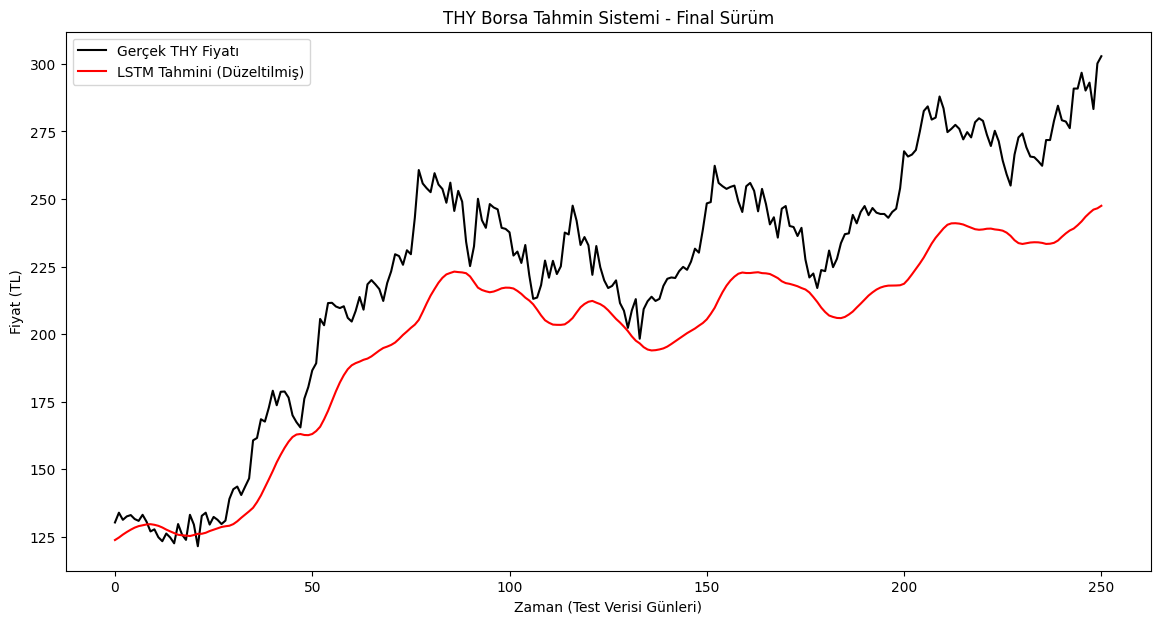

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber # Hatayı önlemek için doğrudan import

# --- 1. VERİ TEMİNİ VE TEMİZLİĞİ ---
def get_clean_data(ticker):
    df = yf.download(ticker, start='2019-01-01', end='2024-04-15')

    # Teknik İndikatörler
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['RSI'] = 50 # Basitlik ve hata önleme için sabit veya hesaplanmış

    # Eksik verileri temizle
    df.fillna(method='ffill', inplace=True)
    df.dropna(inplace=True)

    return df[['Close', 'MA20']]

# --- ANA AKIŞ ---
ticker_symbol = 'THYAO.IS'
data = get_clean_data(ticker_symbol)

# VERİ ÖLÇEKLENDİRME (Ayrı Scaler kullanımı kritik!)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)

look_back = 60
x, y = [], []

for i in range(look_back, len(scaled_data)):
    x.append(scaled_data[i-look_back:i, :]) # Özellikler
    y.append(scaled_data[i, 0]) # Sadece Kapanış Fiyatı (Hedef)

x, y = np.array(x), np.array(y)

# Eğitim/Test Ayrımı
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

# --- 2. MODEL MİMARİSİ ---
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Huber Loss hatasını bu şekilde fixliyoruz
model.compile(optimizer='adam', loss=Huber())

# --- 3. EĞİTİM ---
print("Model optimize ediliyor...")
model.fit(x_train, y_train, batch_size=32, epochs=20, validation_data=(x_test, y_test), verbose=1)

# --- 4. TAHMİN VE DÜZELTME ---
predictions = model.predict(x_test)

# ÖNEMLİ: Ölçeklemeyi geri çevirirken boyut hatasını önlemek
# Tahminleri ters ölçeklemek için orijinal veri formatına (2 sütun) geri sokuyoruz
prediction_copies = np.repeat(predictions, 2, axis=-1)
predictions_final = scaler.inverse_transform(prediction_copies)[:,0]

# Gerçek değerleri ters ölçekleme
y_test_copies = np.repeat(y_test.reshape(-1,1), 2, axis=-1)
actual_final = scaler.inverse_transform(y_test_copies)[:,0]

# --- 5. GÖRSELLEŞTİRME ---
plt.figure(figsize=(14,7))
plt.plot(actual_final, color='black', label='Gerçek THY Fiyatı')
plt.plot(predictions_final, color='red', label='LSTM Tahmini (Düzeltilmiş)')
plt.title('THY Borsa Tahmin Sistemi - Final Sürüm')
plt.xlabel('Zaman (Test Verisi Günleri)')
plt.ylabel('Fiyat (TL)')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(actual_final, predictions_final)
print(f"Ortalama Hata Payı: {error:.2f} TL")

Ortalama Hata Payı: 24.73 TL
